In [82]:
import pandas as pd
import allel
import seaborn as sns
import matplotlib.pyplot as plt


In [9]:
meta = pd.read_csv('../key_files/transcptomic_data_meta.csv')

t = pd.read_csv('../key_files/transcriptomics_data_100t.csv')
t = t.drop('Unnamed: 0',axis=1)

In [21]:
cam5_isoforms = [i for i in t.columns if 'AT2G27030' in i]

t = t.set_index('id')



In [44]:
t.index = t.index.astype(str)

In [92]:
cam5_expresion = t[cam5_isoforms]

In [93]:
cam5_expresion = cam5_expresion['AT2G27030.1']

In [94]:
cam5_expresion_dict = cam5_expresion.to_dict()

In [95]:
clim1001 = pd.read_csv('../key_files/1001g_regmap_grenet_ecotype_info_corrected_bioclim_2024May16.csv')

clim1001['ecotypeid'] = clim1001['ecotypeid'].astype(str)

ecotypeid_to_bio1 = clim1001.set_index('ecotypeid')['bio1'].to_dict()

In [96]:
cam5_annot = pd.read_csv('cam5_annot.csv')

In [97]:
grenenet_ecotypes = pd.read_csv('../key_files/founder_ecotype_frequency.txt', sep = '\t',header=None)[0]

In [98]:
vcf1001 = allel.read_vcf('filtered_cam5_1001g.vcf')

geno = vcf1001['calldata/GT']

geno = geno.sum(axis=2)

geno = pd.DataFrame(geno)

geno.columns = vcf1001['samples']

g1001_chrom_pos = pd.DataFrame({'chrom': vcf1001['variants/CHROM'], 'pos': vcf1001['variants/POS']})

vcf1001 = pd.concat([g1001_chrom_pos, geno],axis=1)

vcf_1001_cam5annot = cam5_annot.merge(vcf1001, on = 'pos')

vcf_1001_cam5annot = vcf_1001_cam5annot.drop('chrom_x',axis=1)



In [99]:
vcf_1001_cam5annot.columns

Index(['pos', 'EFF', 'LOF', 'NMD', 'chrom_y', '10001', '10002', '10004',
       '10005', '10006',
       ...
       '9996', '9997', '9998', '9999', '100001', '100002', '6939', '9940',
       '9977', '9992'],
      dtype='object', length=1142)

In [100]:
bios_maped = vcf_1001_cam5annot.columns[5:].map(cam5_expresion_dict)

new_columns = ['pos', 'EFF', 'LOF', 'NMD', 'chrom_y'] + bios_maped.tolist()
vcf_1001_cam5annot.columns = new_columns



In [101]:
eff_columns = vcf_1001_cam5annot['EFF'].str.split('|', expand=True)

eff_columns.columns = ['Effect', 'Impact', 'Position', 'Change', 'Gene', 'Biotype', 'Rank', 'HGVS.c', 'HGVS.p', 'cdna_pos', 'Other']

eff_columns = eff_columns.drop(['Position', 'Change', 'Gene', 'Biotype', 'cdna_pos', 'Other'],axis=1)

vcf_1001_cam5annot = pd.concat([eff_columns, vcf_1001_cam5annot],axis=1)

In [102]:
vcf_1001_cam5annot.columns.isna()

array([False, False, False, ...,  True,  True, False])

In [103]:
vcf_1001_cam5annot_expresion = vcf_1001_cam5annot.iloc[: , vcf_1001_cam5annot.columns.notna()]

In [104]:
vcf_1001_cam5annot_expresion = vcf_1001_cam5annot_expresion.set_index('HGVS.p')

In [105]:
vcf_1001_cam5annot_expresion = vcf_1001_cam5annot_expresion.iloc[:, 9:].T

In [106]:
vcf_1001_cam5annot_expresion = vcf_1001_cam5annot_expresion.sort_index()

In [107]:
#vcf_1001_cam5annot_expresion = vcf_1001_cam5annot_expresion.T

In [108]:
vcf_1001_cam5annot_expresion

HGVS.p,AT2G27030.1,AT2G27030.2,AT2G27030.2,AT2G27030.2,AT2G27030.2,AT2G27030.2,AT2G27030.2,AT2G27030.2,AT2G27030.2,AT2G27030.2,...,AT2G27030.3,AT2G27030.3,AT2G27030.3,AT2G27030.3,AT2G27030.3,AT2G27030.2,AT2G27030.2,AT2G27030.2,AT2G27030.3,AT2G27035.1
-3.024102,0,2,0,0,0,0,0,0,0,0,...,2,2,2,0,2,0,2,2,0,0
-2.216464,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
-1.812370,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
-1.806302,0,0,0,0,0,0,0,0,0,0,...,2,2,2,0,2,0,2,2,0,0
-1.680522,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0.898869,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0.970873,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0.991592,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1.068599,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


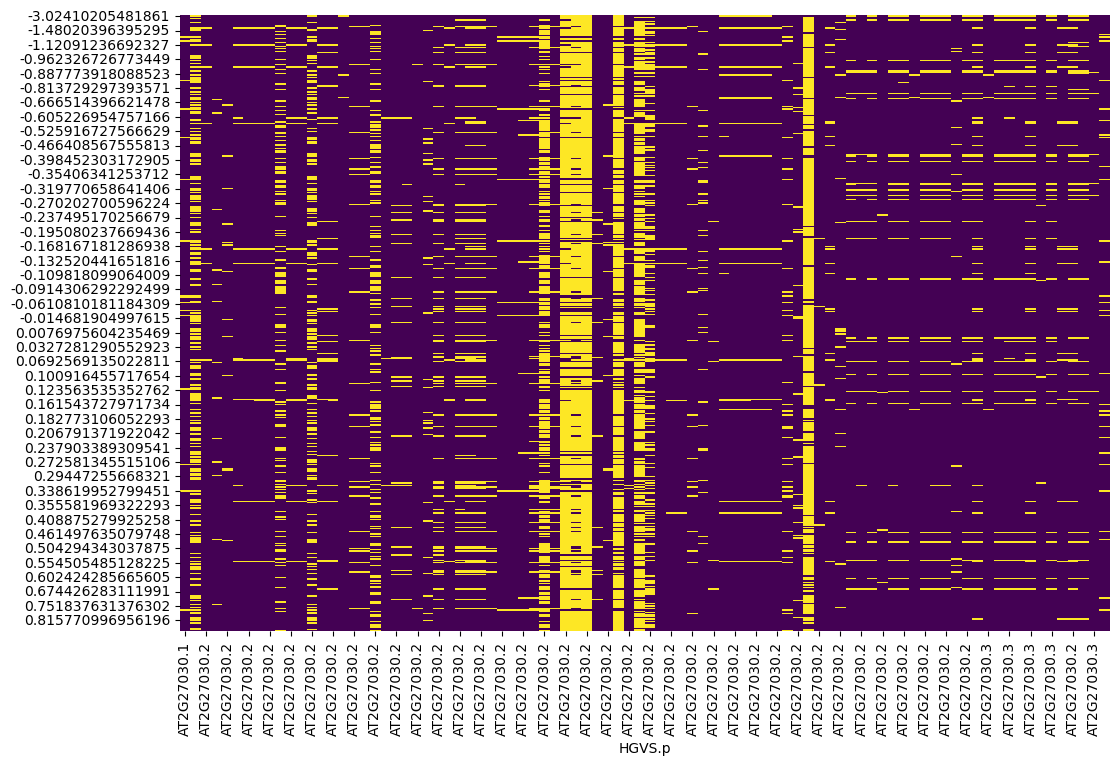

In [109]:
plt.figure(figsize=(12, 8))  # Increase the figure size to make the heatmap bigger
heatmap_plot = sns.heatmap(vcf_1001_cam5annot_expresion, cmap="viridis", cbar=False)

# Show the plot
plt.show()

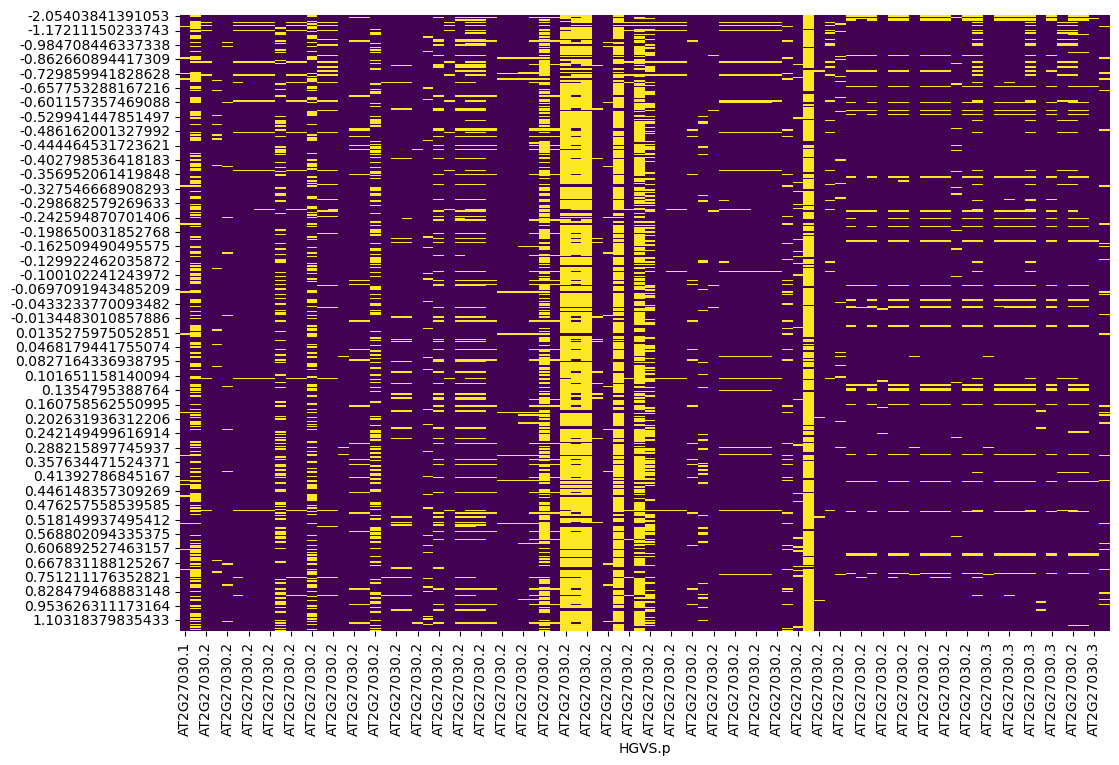

In [91]:
plt.figure(figsize=(12, 8))  # Increase the figure size to make the heatmap bigger
heatmap_plot = sns.heatmap(vcf_1001_cam5annot_expresion, cmap="viridis", cbar=False)

# Show the plot
plt.show()